<div dir="rtl" style="text-align:right">

# 💬 پردازش زبان طبیعی

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SharifiZarchi/IntroAI/blob/main/Session_09/NLP/NLP_Tutorial_FA.ipynb) [![Open in Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https%3A%2F%2Fgithub.com%2FSharifiZarchi%2FIntroAI%2Fblob%2Fmain%2FSession_09%2FNLP%2FNLP_Tutorial_FA.ipynb)

تصویر از همان اول عدد بود. کلمه نیست. این جلسه دو ایده‌ای را می‌گوید که این مشکل را حل کردند و بعد به کارشان می‌گیرد:

۱. ‏One-hot: نمایش بدیهی، و دلیل شکستش

۲. تعبیه کلمات: معنا به‌صورت مختصات، با بردارهای ازپیش‌آموزش‌دیده

۳. لایه ترنسفورمر، پیاده‌سازی از صفر

۴. استفاده از یک ترنسفورمر واقعی ازپیش‌آموزش‌دیده

۵. یک مسابقه Kaggle از ابتدا تا انتها

۶. جمع‌بندی و گام‌های بعدی

پیش‌نیازها: نورون سیگمویدی، softmax و آنتروپی متقاطع، و حلقه آموزش (جلسه‌های ۷ و ۸). **در Colab** همه‌چیز از قبل نصب است و GPU لازم نیست. بخش‌های ۴ و ۵ مدل ازپیش‌آموزش‌دیده دانلود می‌کنند (حدود ۷۰۰ مگابایت، یک بار) و سلول ریزتنظیم بخش ۵ روی CPU حدود چهار دقیقه و روی GPU در Colab کمتر از یک دقیقه است.

**روش اجرا:** روی هر سلول کلیک کن و `Shift + Enter` بزن، به ترتیب از بالا به پایین. هر بخش با تمرین‌هایی تمام می‌شود که راه‌حلشان یک کلیک فاصله دارد.

(کد و مثال‌ها در هر دو نسخه فارسی و انگلیسی دقیقا یکسان و انگلیسی‌اند؛ فقط توضیح‌ها به دو زبان نوشته شده‌اند.)

</div>

<div dir="rtl" style="text-align:right">

---
# بخش ۱: ‏One-hot و دلیل شکستش

مدل عدد می‌خواهد. ترجمه مستقیم به هر کلمه واژگان یک ستون اختصاصی می‌دهد، پس هر کلمه برداری از صفرها با یک عدد ۱ می‌شود. به این می‌گویند بردار **One-hot**:

</div>

In [1]:
import numpy as np

vocabulary = ["cat", "dog", "window", "run"]
one_hot = np.eye(len(vocabulary))

for word, vector in zip(vocabulary, one_hot):
    print(f"{word:8s} {vector}")

cat      [1. 0. 0. 0.]
dog      [0. 1. 0. 0.]
window   [0. 0. 1. 0.]
run      [0. 0. 0. 1.]


<div dir="rtl" style="text-align:right">

دو ایراد بلافاصله ظاهر می‌شوند و هر دو در مقیاس واقعی کشنده‌اند.

**ابعاد.** واژگان واقعی ده‌ها هزار کلمه دارد، پس هر کلمه برداری با ده‌ها هزار عدد می‌شود که فقط یک درایه ناصفر دارد.

**نبود شباهت.** هر کلمه ستون جدا دارد، پس فاصله هر جفت کلمه متمایز یکسان است. این نمایش نمی‌تواند بیان کند که گربه به سگ شبیه‌تر است تا به پنجره:

</div>

In [2]:
for i in range(len(vocabulary)):
    for j in range(i + 1, len(vocabulary)):
        distance = np.linalg.norm(one_hot[i] - one_hot[j])
        print(f"distance({vocabulary[i]:7s}, {vocabulary[j]:7s}) = {distance:.3f}")

distance(cat    , dog    ) = 1.414
distance(cat    , window ) = 1.414
distance(cat    , run    ) = 1.414
distance(dog    , window ) = 1.414
distance(dog    , run    ) = 1.414
distance(window , run    ) = 1.414


<div dir="rtl" style="text-align:right">

همه فاصله‌ها یک عدد واحدند. آن‌چه می‌خواهیم برداری **کوتاه و چگال** برای هر کلمه است که طوری چیده شود که معناهای مشابه نزدیک هم بنشینند. روش استاندارد مقایسه چنین بردارهایی **شباهت کسینوسی** است، یعنی ضرب داخلی بردارهای نرمال‌شده:

$$\cos(a, b) = \frac{a \cdot b}{\|a\| \, \|b\|}$$

برای جهت یکسان ۱+، برای بی‌ربط ۰ و برای مخالف منفی است. با بردارهای دوبعدی دست‌چین‌شده، تفاوتش با One-hot بی‌درنگ دیده می‌شود:

</div>

cos(cat, dog)    = 0.96
cos(cat, window) = 0.14


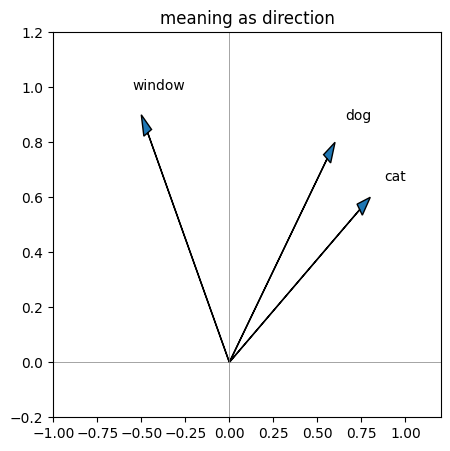

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline

demo_vectors = {"cat": np.array([0.8, 0.6]), "dog": np.array([0.6, 0.8]), "window": np.array([-0.5, 0.9])}

def cosine(a, b):
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)))

print("cos(cat, dog)    =", round(cosine(demo_vectors["cat"], demo_vectors["dog"]), 2))
print("cos(cat, window) =", round(cosine(demo_vectors["cat"], demo_vectors["window"]), 2))

plt.figure(figsize=(5, 5))
for name, v in demo_vectors.items():
    plt.arrow(0, 0, v[0], v[1], head_width=0.05, length_includes_head=True)
    plt.text(v[0] * 1.1, v[1] * 1.1, name)
plt.xlim(-1, 1.2); plt.ylim(-0.2, 1.2)
plt.axhline(0, color="gray", linewidth=0.5); plt.axvline(0, color="gray", linewidth=0.5)
plt.title("meaning as direction")
plt.show()

<div dir="rtl" style="text-align:right">

‏`cat` و `dog` تقریبا یک جهت دارند (۰.۹۶) و `window` جای دیگری را نشان می‌دهد (۰.۱۴). در سیستم واقعی کسی این مختصات را با دست نمی‌نویسد. بخش ۲ از بردارهایی استفاده می‌کند که از میلیاردها کلمه یاد گرفته شده‌اند.

</div>

<div dir="rtl" style="text-align:right">

### ✏️ تمرین ۱
واژگان واقعی انگلیسی حدود ۵۰ هزار کلمه دارد. اگر هر کلمه برداری One-hot از اعداد اعشاری ۳۲ بیتی باشد، یک **جمله ۲۰ کلمه‌ای** چقدر حافظه می‌گیرد؟ حسابش کن و با بردارهای ۵۰ بعدی بخش ۲ مقایسه کن.

</div>

In [4]:
# ✏️ your calculation

vocab_size, sentence_length, bytes_per_float = 50_000, 20, 4
one_hot_bytes = vocab_size * sentence_length * bytes_per_float
dense_bytes = 50 * sentence_length * bytes_per_float
print(f"one-hot: {one_hot_bytes / 1e6:.1f} MB per sentence")
print(f"dense 50-dim: {dense_bytes / 1e3:.1f} kB per sentence")
print("ratio:", one_hot_bytes // dense_bytes)

one-hot: 4.0 MB per sentence
dense 50-dim: 4.0 kB per sentence
ratio: 1000


<div dir="rtl" style="text-align:right">

<details>
<summary>💡 راه‌حل (برای بازشدن کلیک کن)</summary>

```python
vocab_size, sentence_length, bytes_per_float = 50_000, 20, 4
one_hot_bytes = vocab_size * sentence_length * bytes_per_float
dense_bytes = 50 * sentence_length * bytes_per_float
print(f"one-hot: {one_hot_bytes / 1e6:.1f} MB per sentence")
print(f"dense 50-dim: {dense_bytes / 1e3:.1f} kB per sentence")
print("ratio:", one_hot_bytes // dense_bytes)
```

چهار مگابایت برای یک جمله در برابر چهار کیلوبایت، یعنی ضریب هزار، و نسخه One-hot هیچ اطلاعاتی از شباهت هم ندارد. بردارهای چگال هم کوچک‌ترند و هم پرمعناتر، و برای همین هیچ سیستم امروزی برای کلمات از One-hot استفاده نمی‌کند.

</details>

</div>

<div dir="rtl" style="text-align:right">

### ✏️ تمرین ۲
ادعای «همه فاصله‌ها برابرند» را برای واژگان بزرگ‌تر بررسی کن: با `np.eye(100)` بردارهای One-hot برای ۱۰۰ کلمه بساز و بررسی کن که هر فاصله دوتایی برابر همان یک مقدار است. آن مقدار چیست و چرا؟

</div>

In [ ]:
# ✏️ your check



<div dir="rtl" style="text-align:right">

<details>
<summary>💡 راه‌حل (برای بازشدن کلیک کن)</summary>

```python
big = np.eye(100)
distances = [np.linalg.norm(big[i] - big[j]) for i in range(100) for j in range(i + 1, 100)]
print("unique distances:", set(np.round(distances, 6)))
print("sqrt(2) =", round(float(np.sqrt(2)), 6))
```

هر فاصله برابر جذر ۲ است، چون دو بردار One-hot متفاوت دقیقا در دو مختصات و هر کدام به اندازه ۱ تفاوت دارند. هندسه فضا مستقل از این است که کدام کلمه‌ها مقایسه می‌شوند، پس هیچ مفهومی از معنا از آن بیرون نمی‌آید.

</details>

</div>

<div dir="rtl" style="text-align:right">

---
# بخش ۲: تعبیه کلمات

**تعبیه (embedding)** به هر کلمه برداری چگال با چند ده عدد می‌دهد که طوری آموزش دیده که کلمات دارای بافت‌های مشابه بردارهای مشابه بگیرند. وظیفه آموزشی پشت word2vec و GloVe هیچ برچسب انسانی نمی‌خواهد: کلمه را از همسایه‌هایش پیش‌بینی کن، یا همسایه‌ها را از کلمه، روی پیکره‌ای بزرگ. کلماتی که در بافت جابه‌جاشدنی‌اند به هم نزدیک می‌شوند.

آموزش این کار روی میلیاردها کلمه ساعت‌ها طول می‌کشد، پس همان کاری را می‌کنیم که حرفه‌ای‌ها می‌کنند و بردارهای ازپیش‌آموزش‌دیده را بار می‌کنیم. فایل زیر ۲۰ هزار کلمه پربسامد انگلیسی را به‌صورت بردارهای ۵۰ بعدی GloVe نگه می‌دارد که روی ویکی‌پدیا و متن خبری آموزش دیده‌اند:

</div>

In [ ]:
import os
from urllib.request import urlretrieve

BASE_URL = "https://raw.githubusercontent.com/SharifiZarchi/IntroAI/main/Session_09/NLP/"

if not os.path.exists("glove_subset.npz"):
    urlretrieve(BASE_URL + "glove_subset.npz", "glove_subset.npz")

data = np.load("glove_subset.npz")
words = [str(w) for w in data["words"]]
vectors = data["vectors"]
word_to_id = {w: i for i, w in enumerate(words)}

normed = vectors / np.linalg.norm(vectors, axis=1, keepdims=True)
print("vocabulary:", len(words), "words | dimensions:", vectors.shape[1])
print("vector for 'cat':", np.round(vectors[word_to_id["cat"]][:8], 2), "...")

<div dir="rtl" style="text-align:right">

پنجاه عدد برای هر کلمه، و هر کدامشان از متن خام یاد گرفته شده. نزدیک‌ترین همسایه‌ها بر حسب شباهت کسینوسی نشان می‌دهند این عددها چه چیزی را رمزگذاری کرده‌اند:

</div>

In [ ]:
def neighbors(word, k=6):
    similarity = normed @ normed[word_to_id[word]]
    best = similarity.argsort()[::-1][1:k + 1]
    return [words[i] for i in best]

for word in ["cat", "king", "paris", "swim"]:
    print(f"{word:8s} -> {neighbors(word)}")

<div dir="rtl" style="text-align:right">

هیچ‌کدام از این‌ها برچسب‌گذاری نشده بود. ‏`cat` کنار سگ و خرگوش و میمون می‌نشیند و `paris` کنار پایتخت‌های دیگر. هم‌وقوعی در متن کافی بود.

### ۲.۱ حساب با کلمات
اگر جهت معنا داشته باشد، جهت‌ها را می‌شود جمع و تفریق کرد. مثال مشهور `king - man + woman` است:

</div>

In [ ]:
def analogy(a, b, c, k=3):
    target = normed[word_to_id[b]] - normed[word_to_id[a]] + normed[word_to_id[c]]
    target = target / np.linalg.norm(target)
    order = (normed @ target).argsort()[::-1]
    return [words[i] for i in order if words[i] not in (a, b, c)][:k]

print("man : king    :: woman :", analogy("man", "king", "woman"))
print("france : paris :: iran :", analogy("france", "paris", "iran"))
print("small : smaller :: big :", analogy("small", "smaller", "big"))

<div dir="rtl" style="text-align:right">

حساب برداری روی `queen` می‌افتد، روی `tehran` و روی `bigger`. جنسیت، پایتخت کشور، و درجه تفضیلی، جهت‌هایی در این فضا هستند که کسی برنامه‌ریزی‌شان نکرده؛ از دل تابع هدف آموزش بیرون آمده‌اند.

### ۲.۲ دیدن فضا
پنجاه بعد را نمی‌شود کشید، اما PCA (یک تصویرسازی استاندارد) آن را به دو بعد فشرده می‌کند و بیشترین تغییرات را نگه می‌دارد. چهار گروه کلمه، رنگ‌آمیزی‌شده بر حسب گروه:

</div>

In [ ]:
from sklearn.decomposition import PCA

groups = {
    "animals": ["cat", "dog", "horse", "cow", "lion", "tiger"],
    "cities": ["paris", "london", "tokyo", "berlin", "madrid", "rome"],
    "colors": ["red", "blue", "green", "yellow", "black", "white"],
    "verbs": ["run", "walk", "jump", "swim", "eat", "sleep"],
}

selected = [w for group in groups.values() for w in group]
points = PCA(n_components=2, random_state=0).fit_transform(normed[[word_to_id[w] for w in selected]])

plt.figure(figsize=(8, 6))
start = 0
for name, group in groups.items():
    chunk = points[start:start + len(group)]
    plt.scatter(chunk[:, 0], chunk[:, 1], label=name, s=60)
    for (x, y), word in zip(chunk, group):
        plt.text(x + 0.02, y + 0.02, word, fontsize=9)
    start += len(group)
plt.legend(); plt.title("word vectors projected to 2D")
plt.show()

<div dir="rtl" style="text-align:right">

گروه‌ها جدا می‌شوند بدون این‌که هرگز به مدل گفته شده باشد اصلا دسته‌ای وجود دارد. همین ساختار به‌صورت عدد در ماتریس شباهت هم دیده می‌شود:

</div>

In [ ]:
probes = ["cat", "dog", "horse", "paris", "london", "red", "blue", "run"]
P = normed[[word_to_id[w] for w in probes]]

plt.figure(figsize=(6, 5))
plt.imshow(P @ P.T, cmap="viridis")
plt.colorbar(label="cosine similarity")
plt.xticks(range(len(probes)), probes, rotation=45); plt.yticks(range(len(probes)), probes)
plt.title("cosine similarity between word vectors")
plt.show()

<div dir="rtl" style="text-align:right">

### ۲.۳ محدودیت این بردارها
هر کلمه دقیقا **یک** سطر از جدول را دارد، پس کلمه‌ای با چند معنا یک بردار میانگین‌گرفته می‌گیرد. ‏`bank` هم لبه رودخانه است و هم بانک، و همسایه‌هایش این برخورد را نشان می‌دهند:

</div>

In [ ]:
print("bank ->", neighbors("bank", 8))

<div dir="rtl" style="text-align:right">

فهرست پر از واژه‌های مالی است و هیچ‌چیز از معنای رودخانه در آن نیست: معنای غالب در پیکره آموزش برنده می‌شود و آن یکی محو می‌شود. هیچ جدولی با یک سطر برای هر کلمه نمی‌تواند بهتر عمل کند، چون جدول هرگز جمله را نمی‌بیند. رفع این مشکل نمایشی می‌خواهد که **برای هر جمله** حساب شود، و بخش‌های ۳ و ۴ همان را می‌سازند.

</div>

<div dir="rtl" style="text-align:right">

### ✏️ تمرین ۳
همسایه‌های `king` و `computer` و `music` را چاپ کن، بعد کلمه‌ای پیدا کن که همسایه‌هایش غلط یا غافلگیرکننده به نظر برسد و توضیح بده پیکره احتمالا چه چیزی داشته است.

</div>

In [ ]:
# ✏️ your probes



<div dir="rtl" style="text-align:right">

<details>
<summary>💡 راه‌حل (برای بازشدن کلیک کن)</summary>

```python
for word in ["king", "computer", "music", "apple"]:
    print(f"{word:9s} -> {neighbors(word)}")
```

‏`apple` نمونه آموزنده است: همسایه‌هایش به‌جای میوه، برندهای فناوری‌اند، چون ویکی‌پدیا و متن خبری خیلی بیشتر درباره شرکت حرف می‌زنند تا میوه. تعبیه‌ها آینه پیکره‌اند نه فرهنگ لغت، و همین اثر برای نام‌ها و مشاغل و هر کلمه دارای سوگیری اجتماعی هم رخ می‌دهد؛ همان هشدار جلسه ۱، این بار به‌صورت برداری.

</details>

</div>

<div dir="rtl" style="text-align:right">

### ✏️ تمرین ۴
با `analogy(a, b, c)` دو تناسب از خودت بساز، یکی که جواب بدهد و یکی که شکست بخورد. برای شروع: `paris : france :: tokyo : ?` و `walking : walked :: swimming : ?`

</div>

In [ ]:
# ✏️ your analogies



<div dir="rtl" style="text-align:right">

<details>
<summary>💡 راه‌حل (برای بازشدن کلیک کن)</summary>

```python
print("paris : france :: tokyo :", analogy("paris", "france", "tokyo"))
print("walking : walked :: swimming :", analogy("walking", "walked", "swimming"))
```

تناسب کشور جواب می‌دهد (`japan`) و تناسب زمان فعل نه: واژه‌های ورزشی برمی‌گرداند، چون در فضای ۵۰ بعدی آموزش‌دیده روی متن خبری، `swimming` به المپیک نزدیک‌تر است تا به زمان گذشته خودش. تناسب‌ها خاصیت واقعی این فضا هستند اما قابل‌اتکا نیستند، به‌ویژه با بردارهای کوچک و صورت‌های کمیاب کلمه.

</details>

</div>

<div dir="rtl" style="text-align:right">

### ✏️ تمرین ۵
با بردارها معمای «کدام یکی جور نیست» را حل کن: برای `["cat", "dog", "horse", "paris"]` بردار میانگین گروه را حساب کن و کلمه‌ای را گزارش بده که کمترین شباهت کسینوسی را با آن دارد. برای `["red", "blue", "green", "run"]` هم جواب می‌دهد؟

</div>

In [ ]:
# ✏️ odd one out



<div dir="rtl" style="text-align:right">

<details>
<summary>💡 راه‌حل (برای بازشدن کلیک کن)</summary>

```python
def odd_one_out(group):
    matrix = normed[[word_to_id[w] for w in group]]
    center = matrix.mean(axis=0)
    center = center / np.linalg.norm(center)
    scores = matrix @ center
    return group[int(scores.argmin())]

print(odd_one_out(["cat", "dog", "horse", "paris"]))
print(odd_one_out(["red", "blue", "green", "run"]))
```

هر دو معما درست حل می‌شوند. کل ترفند پشت جست‌وجوی معنایی و پیشنهاد بر اساس محتوا همین است: چیزها را بردار کن، بعد زاویه‌ها را بسنج. چیز پیچیده‌تری لازم نیست.

</details>

</div>

<div dir="rtl" style="text-align:right">

---
# بخش ۳: لایه ترنسفورمر، پیاده‌سازی‌شده

بردار کلمه‌ای که جمله را نادیده می‌گیرد نمی‌تواند ابهام `bank` را حل کند. **توجه (attention)** این را حل می‌کند: می‌گذارد هر توکن به همه توکن‌های دیگر نگاه کند و از آن‌چه می‌یابد میانگین وزن‌دار بگیرد، با وزن‌هایی که از خود محتوا حساب می‌شوند.

هر توکن با سه ماتریس یادگرفتنی سه بردار می‌سازد:

- **پرسش (Query)** $Q$: دنبال چه می‌گردم؟
- **کلید (Key)** $K$: چه چیزی عرضه می‌کنم؟
- **محتوا (Value)** $V$: اگر انتخاب شدم چه منتقل می‌کنم؟

امتیاز توجه توکن $i$ به توکن $j$ ضرب داخلی $Q_i$ و $K_j$ است. ‏softmax امتیازهای یک توکن را به وزن‌هایی تبدیل می‌کند که جمعشان ۱ است، و خروجی جمع وزن‌دار محتواهاست:

$$\text{scores} = \frac{Q K^{\top}}{\sqrt{d}}, \qquad \text{weights} = \text{softmax}(\text{scores}), \qquad \text{output} = \text{weights} \cdot V$$

کل این سازوکار نه خط PyTorch است:

</div>

In [ ]:
import torch

def attention(X, Wq, Wk, Wv, mask=None):
    Q, K, V = X @ Wq, X @ Wk, X @ Wv
    d = Q.shape[-1]
    scores = Q @ K.transpose(-2, -1) / d ** 0.5
    if mask is not None:
        scores = scores.masked_fill(mask, float("-inf"))
    weights = torch.softmax(scores, dim=-1)
    return weights @ V, weights

print("attention implemented ✅")

In [ ]:
torch.manual_seed(0)

sentence = ["the", "player", "kicked", "the", "ball", "hard"]
n, d = len(sentence), 16

X = torch.randn(n, d)                                   # one vector per token
Wq, Wk, Wv = torch.randn(d, d), torch.randn(d, d), torch.randn(d, d)

output, weights = attention(X, Wq, Wk, Wv)

print("input:", tuple(X.shape), "-> output:", tuple(output.shape))
print("each row of weights sums to:", weights.sum(dim=-1).round(decimals=3).tolist())

<div dir="rtl" style="text-align:right">

دو واقعیت ساختاری. خروجی هم‌ابعاد ورودی است، پس لایه‌ها روی هم می‌نشینند. و جمع هر سطر ۱ است: هر توکن بودجه ثابتی از توجه دارد که بین کلمات جمله پخش می‌کند. وزن‌ها یک ماتریس‌اند، پس نمایش دادنی‌اند:

</div>

In [ ]:
plt.figure(figsize=(5.5, 4.5))
plt.imshow(weights.detach(), cmap="viridis")
plt.colorbar(label="attention weight")
plt.xticks(range(n), sentence, rotation=45); plt.yticks(range(n), sentence)
plt.xlabel("attended to"); plt.ylabel("attending from")
plt.title("attention weights (random matrices)")
plt.show()

<div dir="rtl" style="text-align:right">

الگوی این‌جا معنایی ندارد: سه ماتریس تصادفی‌اند. در شبکه واقعی این‌ها مثل هر وزن دیگری با گرادیان کاهشی آموزش می‌بینند، و بخش ۴ نتیجه را درون یک مدل ازپیش‌آموزش‌دیده نشان می‌دهد.

### ۳.۱ چرا تقسیم بر جذر بعد
ضرب داخلی در ابعاد بالاتر جمع جمله‌های بیشتری است، پس امتیازها با $d$ بزرگ می‌شوند. امتیاز بزرگ softmax را اشباع می‌کند: یک توکن تقریبا همه وزن را می‌گیرد، بقیه نزدیک صفر می‌گیرند و گرادیان تقریبا محو می‌شود؛ همان مشکل اشباع جلسه ۷:

</div>

In [ ]:
raw_scores = torch.tensor([8.0, 4.0, 2.0])

print("without scaling:", torch.softmax(raw_scores, dim=0).round(decimals=3).tolist())
print("divided by 8:   ", torch.softmax(raw_scores / 8, dim=0).round(decimals=3).tolist())

<div dir="rtl" style="text-align:right">

### ۳.۲ ماسک علی
مدلی که متن تولید می‌کند نباید آینده‌ای را بخواند که دارد پیش‌بینی‌اش می‌کند. صفرکردن آن امتیازها با منفی بی‌نهایت پیش از softmax، وزنشان را دقیقا صفر می‌کند:

</div>

In [ ]:
causal_mask = torch.triu(torch.ones(n, n, dtype=torch.bool), diagonal=1)
_, masked_weights = attention(X, Wq, Wk, Wv, mask=causal_mask)

plt.figure(figsize=(5.5, 4.5))
plt.imshow(masked_weights.detach(), cmap="viridis")
plt.colorbar(label="attention weight")
plt.xticks(range(n), sentence, rotation=45); plt.yticks(range(n), sentence)
plt.title("causal mask: nobody reads the future")
plt.show()

<div dir="rtl" style="text-align:right">

ماتریس پایین‌مثلثی است. مدل‌هایی که این‌طور ساخته می‌شوند (GPT و خویشاوندانش) فقط‌رمزگشا نام دارند و مدل‌های بدون ماسک (BERT و خویشاوندانش) جمله را دوطرفه می‌خوانند.

### ۳.۳ لایه کامل
لایه ترنسفورمر واقعی سه چیز به توجه بالا اضافه می‌کند. **توجه چندسر** چند توجه را موازی روی برش‌هایی از بردار اجرا می‌کند، پس با $d_{model} = 512$ و ۸ سر، هر سر در ۶۴ بعد کار می‌کند و خروجی‌ها کنار هم دوباره ۵۱۲ می‌شوند. **اتصال‌های باقی‌مانده** ورودی را به خروجی اضافه می‌کنند، دقیقا مثل ResNet جلسه ۸. **نرمال‌سازی لایه** فعال‌سازی‌ها را در محدوده پایدار نگه می‌دارد:

</div>

In [ ]:
from torch import nn

class TransformerLayer(nn.Module):
    def __init__(self, d_model, heads):
        super().__init__()
        self.attention = nn.MultiheadAttention(d_model, heads, batch_first=True)
        self.feed_forward = nn.Sequential(
            nn.Linear(d_model, 4 * d_model), nn.ReLU(), nn.Linear(4 * d_model, d_model))
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        h = self.norm1(x)
        x = x + self.attention(h, h, h, need_weights=False)[0]     # tokens talk to each other
        return x + self.feed_forward(self.norm2(x))                # each token thinks alone

layer = TransformerLayer(d_model=512, heads=8)
print("parameters in one layer:", sum(p.numel() for p in layer.parameters()))

dummy = torch.randn(1, 10, 512)          # batch of 1, sentence of 10 tokens
print("input:", tuple(dummy.shape), "-> output:", tuple(layer(dummy).shape))

<div dir="rtl" style="text-align:right">

حدود ۳.۱۵ میلیون پارامتر، و ابعاد خروجی برابر ابعاد ورودی است، و برای همین لایه‌ها مستقیم روی هم می‌نشینند: ۱۲ تا در GPT-2 کوچک و ۹۶ تا در GPT-3.

### ۳.۴ مکان باید اضافه شود
توجه ورودی‌اش را مجموعه می‌بیند. توکن‌ها را جابه‌جا کن، همان وزن‌ها روی همان جفت‌ها حساب می‌شود، پس «علی به سارا کتاب داد» و «سارا به علی کتاب داد» یکسان می‌شدند. راه‌حل، افزودن یک **بردار مکان** به هر توکن پیش از لایه اول است، به‌طور کلاسیک موج‌های سینوسی با فرکانس‌های مختلف:

</div>

In [ ]:
def positional_encoding(length, d_model):
    pos = torch.arange(length).unsqueeze(1)
    i = torch.arange(0, d_model, 2)
    angle = pos / (10000 ** (i / d_model))
    pe = torch.zeros(length, d_model)
    pe[:, 0::2] = torch.sin(angle)
    pe[:, 1::2] = torch.cos(angle)
    return pe

plt.figure(figsize=(8, 3.5))
plt.imshow(positional_encoding(60, 128).T, cmap="RdBu", aspect="auto")
plt.colorbar(label="value")
plt.xlabel("position in the sentence"); plt.ylabel("dimension")
plt.title("positional encoding")
plt.show()

<div dir="rtl" style="text-align:right">

هر موقعیت الگوی منحصربه‌فردی از موج‌ها می‌گیرد، مثل عقربه‌های ساعت با سرعت‌های متفاوت، تا توجه بتواند «کلمه اول» را از «کلمه پنجم» تشخیص دهد.

</div>

<div dir="rtl" style="text-align:right">

### ✏️ تمرین ۶
خاصیت بودجه را عددی بررسی کن: با `torch.allclose` تأیید کن جمع هر سطر `weights` برابر ۱ است و برای `masked_weights` هم همین‌طور، با وجود این‌که خیلی از درایه‌هایش صفرند. سطر ۲ ماسک‌شده را چاپ کن تا ببینی بودجه چطور بازتوزیع شده.

</div>

In [ ]:
# ✏️ your check



<div dir="rtl" style="text-align:right">

<details>
<summary>💡 راه‌حل (برای بازشدن کلیک کن)</summary>

```python
ones = torch.ones(n)
print(torch.allclose(weights.sum(dim=-1), ones, atol=1e-5))
print(torch.allclose(masked_weights.sum(dim=-1), ones, atol=1e-5))
print(masked_weights[2].round(decimals=3).tolist())
```

هر دو برقرارند. ماسک بودجه را حذف نمی‌کند بلکه بازتوزیعش می‌کند: سطر ۲ کل ۱.۰ را روی سه موقعیت اول پخش می‌کند و به بقیه دقیقا صفر می‌دهد.

</details>

</div>

<div dir="rtl" style="text-align:right">

### ✏️ تمرین ۷
مقیاس‌دهی را بردار: وزن‌ها را با `Q @ K.transpose(-2, -1)` و بدون تقسیم حساب کن و بیشینه وزن هر سطر را با نسخه مقیاس‌دهی‌شده مقایسه کن. ‏softmax بدون مقیاس چقدر تیزتر می‌شود؟

</div>

In [ ]:
# ✏️ unscaled attention



<div dir="rtl" style="text-align:right">

<details>
<summary>💡 راه‌حل (برای بازشدن کلیک کن)</summary>

```python
Q, K = X @ Wq, X @ Wk
unscaled = torch.softmax(Q @ K.transpose(-2, -1), dim=-1)

print("scaled max per row:  ", weights.max(dim=-1).values.round(decimals=2).tolist())
print("unscaled max per row:", unscaled.max(dim=-1).values.round(decimals=2).tolist())
```

سطرهای بدون مقیاس تقریبا همه وزنشان را روی یک توکن می‌گذارند، نزدیک ۱.۰۰. ‏softmax اشباع‌شده تقریبا هیچ گرادیانی عبور نمی‌دهد، پس لایه به‌سختی یاد می‌گیرد، و دقیقا به همین دلیل جذر $d$ در فرمول هست.

</details>

</div>

<div dir="rtl" style="text-align:right">

### ✏️ تمرین ۸
ماسک علی را بدون `torch.triu` بساز: یک تنسور بولی `n` در `n` که درایه `[i, j]` آن وقتی `True` است که `j > i`، و برابری‌اش را با `causal_mask` تأیید کن.

</div>

In [ ]:
# ✏️ your mask



<div dir="rtl" style="text-align:right">

<details>
<summary>💡 راه‌حل (برای بازشدن کلیک کن)</summary>

```python
rows = torch.arange(n).unsqueeze(1)
cols = torch.arange(n).unsqueeze(0)
print(torch.equal(cols > rows, causal_mask))
```

ماسک فقط همان مقایسه «آیا این موقعیت در آینده است» است. علیت در مدل زبانی یک ماتریس بولی است، نه الگوریتمی خاص.

</details>

</div>

<div dir="rtl" style="text-align:right">

### ✏️ تمرین ۹
تعداد پارامترهای یک لایه را با دست برای $d_{model} = 768$ و ۱۲ سر حساب کن، یعنی پیکربندی BERT-base: سه ماتریس $Q$ و $K$ و $V$ به ابعاد $d \times d$، یک ماتریس خروجی $d \times d$، و جفت پیش‌خور $d \times 4d$ و $4d \times d$. بعد با `TransformerLayer` بررسی کن.

</div>

In [ ]:
# ✏️ hand computation, then the check



<div dir="rtl" style="text-align:right">

<details>
<summary>💡 راه‌حل (برای بازشدن کلیک کن)</summary>

```python
d = 768
by_hand = 4 * (d * d) + (d * 4 * d) + (4 * d * d)
print("weights only, by hand:", by_hand)
print("actual:", sum(p.numel() for p in TransformerLayer(768, 12).parameters()))
```

حدود ۷.۰۸ میلیون وزن با دست و حدود ۷.۰۹ میلیون در مجموع، که تفاوتش بایاس‌ها و دو لایه نرمال‌سازی است. دوازده تا از این لایه‌ها همان ۸۵ میلیون پارامتر ترنسفورمر BERT-base را می‌دهد.

</details>

</div>

<div dir="rtl" style="text-align:right">

### ✏️ تمرین ۱۰
نشان بده توجه بدون رمزگذاری مکانی به ترتیب کور است: یک `X` کوچک با ۴ بردار توکن بساز، توجه را حساب کن، بعد ترتیب توکن‌ها را برعکس کن و دوباره حساب کن. خروجی‌ها را پس از برگرداندن ترتیب مقایسه کن.

</div>

In [ ]:
# ✏️ order test



<div dir="rtl" style="text-align:right">

<details>
<summary>💡 راه‌حل (برای بازشدن کلیک کن)</summary>

```python
Xs = torch.randn(4, 16)
Wq4, Wk4, Wv4 = torch.randn(16, 16), torch.randn(16, 16), torch.randn(16, 16)

out_a, _ = attention(Xs, Wq4, Wk4, Wv4)
out_b, _ = attention(Xs.flip(0), Wq4, Wk4, Wv4)
print(torch.allclose(out_a, out_b.flip(0), atol=1e-5))
```

نتیجه `True` است: برعکس‌کردن ورودی فقط خروجی را برعکس می‌کند، پس هر توکن دقیقا همان چیزی را حساب کرده که قبلا. اطلاعات ترتیب باید جداگانه تزریق شود و کار رمزگذاری مکانی همین است.

</details>

</div>

<div dir="rtl" style="text-align:right">

---
# بخش ۴: استفاده از یک ترنسفورمر واقعی ازپیش‌آموزش‌دیده

همان ماشین‌آلات، آموزش‌دیده روی میلیاردها کلمه و قابل دانلود در سه خط. از BERT استفاده می‌کنیم، یک ترنسفورمر فقط‌رمزگذار (بدون ماسک علی، پس هر توکن کل جمله را می‌خواند). دو نکته در بارگذاری مهم است. خط `USE_TF` کاری می‌کند که `transformers` روی PyTorch بماند، هماهنگ با بقیه دوره، و `attn_implementation="eager"` پیاده‌سازی ساده توجه را می‌خواهد: پیاده‌سازی پیش‌فرض و سریع‌تر (SDPA) محاسبه را در هم ادغام می‌کند و ماتریس وزن را اصلا نمی‌سازد، پس بخش ۴.۳ نمی‌توانست نمایشش دهد.

</div>

In [ ]:
import os
os.environ["USE_TF"] = "0"

from transformers import AutoTokenizer, AutoModel

model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
bert = AutoModel.from_pretrained(model_name, attn_implementation="eager").eval()

print("parameters:", sum(p.numel() for p in bert.parameters()))
print("vocabulary size:", tokenizer.vocab_size)

<div dir="rtl" style="text-align:right">

### ۴.۱ توکن‌های زیرواژه‌ای
سیستم‌های واقعی از کلمه کامل استفاده نمی‌کنند. واژگان فهرست ثابتی از حدود ۳۰ هزار قطعه **زیرواژه** است، پس کلمات رایج یک توکن‌اند، کلمات کمیاب تجزیه می‌شوند و هیچ ورودی‌ای هرگز خارج از واژگان نیست:

</div>

In [ ]:
for text in ["the player kicked the ball", "unbelievable", "zorgomatic"]:
    print(f"{text!r} -> {tokenizer.tokenize(text)}")

<div dir="rtl" style="text-align:right">

### ۴.۲ بردارهای بافتاری ابهام را حل می‌کنند
این همان دستاورد است. بخش ۲ با این نکته تمام شد که `bank` یک بردار میانگین‌گرفته دارد. این‌جا مدل برای آن توکن **در هر جمله** یک بردار حساب می‌کند، پس می‌شود سنجید که آیا دو معنا از هم جدا می‌شوند. سه جمله، دو تا با معنای رودخانه و یکی با معنای مالی:

</div>

In [ ]:
sentences = ["he sat on the river bank",
             "the boat reached the muddy river bank",
             "he went to the bank to deposit money"]

token_vectors = []
for s in sentences:
    encoded = tokenizer(s, return_tensors="pt")
    pieces = tokenizer.convert_ids_to_tokens(encoded["input_ids"][0])
    with torch.no_grad():
        hidden = bert(**encoded).last_hidden_state[0]
    token_vectors.append(hidden[pieces.index("bank")])

V = torch.stack(token_vectors)
V = V / V.norm(dim=1, keepdim=True)
similarity = (V @ V.T).numpy()

for i, s in enumerate(sentences):
    print(i, "=", s)
print(np.round(similarity, 2))

<div dir="rtl" style="text-align:right">

دو جمله رودخانه با هم حدود ۰.۸۰ امتیاز می‌گیرند، در حالی که رودخانه در برابر پول حدود ۰.۳۲ است. یک واژه ورودی یکسان **بردارهای متفاوت** تولید کرد که جایشان را کلمات اطراف تعیین کرده‌اند. جدول ایستا هرگز نمی‌توانست چنین کند؛ توجه است که این را ممکن می‌کند، چون بعد از هر لایه بردار یک توکن آمیخته‌ای وزن‌دار از همسایه‌هایش است.

### ۴.۳ توجه خود مدل
وزن‌های درون مدل ازپیش‌آموزش‌دیده استخراج‌شدنی‌اند و همان شیئی هستند که در بخش ۳ ساختیم:

</div>

In [ ]:
encoded = tokenizer("the player kicked the ball and it shook the goal", return_tensors="pt")
pieces = tokenizer.convert_ids_to_tokens(encoded["input_ids"][0])
with torch.no_grad():
    outputs = bert(**encoded, output_attentions=True)

print("layers:", len(outputs.attentions), "| heads per layer:", outputs.attentions[0].shape[1])

attention_map = outputs.attentions[5][0].mean(dim=0)      # layer 6, averaged over heads

plt.figure(figsize=(7, 6))
plt.imshow(attention_map, cmap="viridis")
plt.colorbar(label="attention weight")
plt.xticks(range(len(pieces)), pieces, rotation=90); plt.yticks(range(len(pieces)), pieces)
plt.title("real attention weights (layer 6, head-averaged)")
plt.show()

<div dir="rtl" style="text-align:right">

پایین‌مثلثی نیست، چون BERT دوطرفه می‌خواند. سرها تک‌تک تخصصی می‌شوند، بعضی واژه‌های مجاور را دنبال می‌کنند و بعضی روابط نحوی را، و خیلی‌هایشان اصلا تفسیرپذیر نیستند، دقیقا مثل فیلترهای CNN جلسه ۸.

### ۴.۴ مدل‌های آماده
برای بیشتر کاربردها اصلا لازم نیست چیزی ساخته شود. مدلی با سر دسته‌بندی که روی نقدهای برچسب‌خورده ریزتنظیم شده سه خط فاصله دارد، و این همان دستور یادگیری انتقالی جلسه ۸ است که برای زبان به کار رفته:

</div>

In [ ]:
from transformers import AutoModelForSequenceClassification

sentiment_name = "distilbert-base-uncased-finetuned-sst-2-english"
sentiment_tokenizer = AutoTokenizer.from_pretrained(sentiment_name)
sentiment_model = AutoModelForSequenceClassification.from_pretrained(sentiment_name).eval()

for text in ["this movie was really great", "the quality was awful and I was not satisfied"]:
    with torch.no_grad():
        probs = sentiment_model(**sentiment_tokenizer(text, return_tensors="pt")).logits.softmax(dim=-1)[0]
    label = sentiment_model.config.id2label[int(probs.argmax())]
    print(f"{text!r} -> {label} ({probs.max():.2f})")

<div dir="rtl" style="text-align:right">

### ✏️ تمرین ۱۱
ادعای بافتاری‌بودن را روی واژه‌ای از خودت بیازما. یک واژه چندمعنایی انگلیسی بردار (`bat`، `spring`، `light`، `match`)، دو جمله با یک معنا و یک جمله با معنای دیگر بنویس، و بررسی کن که جفت هم‌معنا امتیاز بالاتری بگیرد.

</div>

In [ ]:
# ✏️ your three sentences and their similarity matrix



<div dir="rtl" style="text-align:right">

<details>
<summary>💡 راه‌حل (برای بازشدن کلیک کن)</summary>

```python
my_sentences = ["the bat flew out of the dark cave",
                "a small bat hung from the ceiling of the cave",
                "he swung the bat and hit the ball"]

vecs = []
for s in my_sentences:
    enc = tokenizer(s, return_tensors="pt")
    toks = tokenizer.convert_ids_to_tokens(enc["input_ids"][0])
    with torch.no_grad():
        h = bert(**enc).last_hidden_state[0]
    vecs.append(h[toks.index("bat")])

Vm = torch.stack(vecs)
Vm = Vm / Vm.norm(dim=1, keepdim=True)
print(np.round((Vm @ Vm.T).numpy(), 2))
```

دو جمله حیوان به هم نزدیک‌ترند تا به جمله ورزشی. اثر قابل‌اتکاست اما بی‌نقص نیست: جمله کوتاه بافت کمتری به توجه می‌دهد.

</details>

</div>

<div dir="rtl" style="text-align:right">

### ✏️ تمرین ۱۲
بافتاری‌شدن تدریجی است. بردارهای `bank` را از **اولین** لایه و از آخرین لایه بگیر (`bert(**enc, output_hidden_states=True).hidden_states[k]`) و برای هر دو ماتریس شباهت را حساب کن. در کدام لایه معناها بیشتر جدا شده‌اند؟

</div>

In [ ]:
# ✏️ early layer versus late layer



<div dir="rtl" style="text-align:right">

<details>
<summary>💡 راه‌حل (برای بازشدن کلیک کن)</summary>

```python
def bank_vectors(layer_index):
    vs = []
    for s in sentences:
        enc = tokenizer(s, return_tensors="pt")
        toks = tokenizer.convert_ids_to_tokens(enc["input_ids"][0])
        with torch.no_grad():
            hs = bert(**enc, output_hidden_states=True).hidden_states
        vs.append(hs[layer_index][0][toks.index("bank")])
    Vx = torch.stack(vs)
    return Vx / Vx.norm(dim=1, keepdim=True)

for layer_index in (1, 12):
    Vx = bank_vectors(layer_index)
    print("layer", layer_index, "\n", np.round((Vx @ Vx.T).numpy(), 2))
```

لایه‌های ابتدایی هر سه بردار را نزدیک هم نگه می‌دارند، چون هنوز به تعبیه ایستا نزدیک‌اند، و لایه‌های بعدی معناها را جدا می‌کنند. هر لایه کمی بیشتر از جمله اطراف را می‌آمیزد.

</details>

</div>

<div dir="rtl" style="text-align:right">

### ✏️ تمرین ۱۳
مدل احساسات را روی سه جمله از خودت اجرا کن، از جمله یکی کنایه‌آمیز. کجا شکست می‌خورد و این درباره خواندن عدد اطمینان چه می‌گوید؟

</div>

In [ ]:
# ✏️ your sentences



<div dir="rtl" style="text-align:right">

<details>
<summary>💡 راه‌حل (برای بازشدن کلیک کن)</summary>

```python
for text in ["the food was fine I guess",
             "great, another delayed flight",
             "I have never seen anything like this"]:
    with torch.no_grad():
        probs = sentiment_model(**sentiment_tokenizer(text, return_tensors="pt")).logits.softmax(dim=-1)[0]
    label = sentiment_model.config.id2label[int(probs.argmax())]
    print(f"{text!r} -> {label} ({probs.max():.2f})")
```

کنایه شکست استاندارد است: «great, another delayed flight» معمولا با اطمینان بالا مثبت برچسب می‌خورد، چون واژه‌های سطحی مثبت‌اند و نقدهای کنایه‌آمیز در داده آموزش کم‌اند. اطمینان بالا گواه درستی نیست، درسی که این دوره از جلسه ۵ تکرار کرده است.

</details>

</div>

<div dir="rtl" style="text-align:right">

---
# بخش ۵: یک مسابقه Kaggle از ابتدا تا انتها

بخش‌های ۱ تا ۴ ایده‌ها را ساختند. این بخش خود کار است: یک مسابقه واقعی بردار، راه‌حل بساز، صادقانه اندازه بگیر، و فایل ارسال تولید کن.

مسابقه [Natural Language Processing with Disaster Tweets](https://www.kaggle.com/competitions/nlp-getting-started) است، نقطه ورود استاندارد دسته‌بندی متن. مسئله دقیقا به همان شکلی ظریف است که این جلسه پیش‌بینی می‌کند: توییتی که کلمه «آتش» یا «سیل» دارد ممکن است خبر یک فاجعه واقعی باشد، یا استعاره و کنایه و تکه‌ای از یک ترانه. کیسه کلمات فقط کلمه را می‌بیند؛ تنها بافت معنا را تعیین می‌کند.

داده وقتی نوت‌بوک روی Kaggle اجرا شود از آن‌جا خوانده می‌شود و در غیر این صورت از یک آینه عمومی:

</div>

In [ ]:
import os
import pandas as pd

KAGGLE_PATH = "/kaggle/input/nlp-getting-started"
MIRROR = "https://raw.githubusercontent.com/Satwato/Kaggle-NLP-with-Disaster-Tweets/master"
source = KAGGLE_PATH if os.path.exists(KAGGLE_PATH) else MIRROR

train = pd.read_csv(f"{source}/train.csv")
test = pd.read_csv(f"{source}/test.csv")

print("train:", train.shape, "| test:", test.shape)
print("columns:", list(train.columns))
train.head(3)

<div dir="rtl" style="text-align:right">

### ۵.۱ اول به داده نگاه کن
قاعده جلسه ۵ برای متن هم برقرار است: پیش از مدل‌سازی، نگاه کن.

</div>

In [ ]:
print("labels:", train["target"].value_counts().to_dict())
print("missing values:", train.isna().sum().to_dict())

for label in (1, 0):
    example = train[train.target == label].iloc[0]["text"]
    print(f"\ntarget={label}: {example}")

<div dir="rtl" style="text-align:right">

‏۷۶۱۳ توییت برچسب‌خورده که ۴۳ درصدشان فاجعه واقعی‌اند، به‌علاوه ۳۲۶۳ توییت بدون برچسب برای پیش‌بینی. دو ستون جانبی هم هست، `keyword` (تقریبا کامل) و `location` (یک‌سوم جاافتاده و پر از متن آزاد)، که تمرین‌ها سراغشان می‌روند. توزیع‌ها:

</div>

In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.5))
train["target"].value_counts().sort_index().plot(kind="bar", ax=ax1, color=["steelblue", "coral"])
ax1.set_xticklabels(["not disaster", "disaster"], rotation=0); ax1.set_title("class balance")

ax2.hist([train[train.target == 0]["text"].str.len(), train[train.target == 1]["text"].str.len()],
         bins=25, label=["not disaster", "disaster"], color=["steelblue", "coral"])
ax2.set_xlabel("characters per tweet"); ax2.legend(); ax2.set_title("length distribution")
plt.tight_layout(); plt.show()

<div dir="rtl" style="text-align:right">

کلاس‌ها تقریبا متوازن‌اند و طول‌ها تقریبا کامل روی هم می‌افتند، پس طول هیچ سیگنالی ندارد. کار را باید کلمه‌ها انجام دهند.

### ۵.۲ معیار: F1، نه دقت
مسابقه ارسال‌ها را با **معیار F1** روی کلاس فاجعه نمره می‌دهد، یعنی میانگین هارمونیک صحت و بازیابی:

$$\text{precision} = \frac{TP}{TP + FP}, \qquad \text{recall} = \frac{TP}{TP + FN}, \qquad F_1 = 2\,\frac{\text{precision} \times \text{recall}}{\text{precision} + \text{recall}}$$

صحت می‌پرسد از توییت‌های علامت‌خورده چند تا واقعا فاجعه بودند؛ بازیابی می‌پرسد از فاجعه‌های واقعی چند تا گرفته شدند. دقت اجازه می‌داد مدلی با نادیده‌گرفتن کلاس اقلیت برنده شود، و برای ابزار امدادرسانی این انگیزه غلطی است، و F1 مدل را مجبور می‌کند در هر دو خوب باشد.

</div>

<div dir="rtl" style="text-align:right">

### ۵.۳ راه‌حل ۱: خط پایه کیسه کلمات
با خط پایه کلاسیک کیسه کلمات شروع کن. **TF-IDF** هر توییت را به برداری از شمارش وزن‌دار کلمات تبدیل می‌کند، که وزن هر کلمه برابر است با تعداد تکرارش در توییت ضرب در لگاریتم نادر بودنش در کل توییت‌ها:

$$\text{tfidf}(w, d) = \text{count}(w, d) \times \log\frac{N}{\text{df}(w)}$$

پس کلماتی که همه‌جا هستند (مثل the) تقریبا وزنی نمی‌گیرند. دسته‌بند روی آن `LogisticRegression` است، یعنی دقیقا همان نورون سیگمویدی جلسه ۷ با هزاران ستون کلمه به‌عنوان ورودی. خط پایه هست تا شکسته شود، و تا نشان دهد چه بخشی از مسئله آسان است:

</div>

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix

text_train, text_val, y_train_k, y_val_k = train_test_split(
    train["text"], train["target"], test_size=0.2, random_state=42, stratify=train["target"])

tfidf_model = make_pipeline(TfidfVectorizer(), LogisticRegression(max_iter=1000))
tfidf_model.fit(text_train, y_train_k)
pred_tfidf = tfidf_model.predict(text_val)

print("F1:       ", round(f1_score(y_val_k, pred_tfidf), 3))
print("precision:", round(precision_score(y_val_k, pred_tfidf), 3))
print("recall:   ", round(recall_score(y_val_k, pred_tfidf), 3))
print("accuracy: ", round((pred_tfidf == y_val_k).mean(), 3))

<div dir="rtl" style="text-align:right">

‏F1 برابر ۰.۷۶۴، با صحت بالاتر از بازیابی: مدل محتاط است و به‌جای هشدار اشتباه، فاجعه‌های واقعی را از دست می‌دهد. ماتریس درهم‌ریختگی نشان می‌دهد خطاها کجا هستند:

</div>

In [ ]:
cm = confusion_matrix(y_val_k, pred_tfidf)

plt.figure(figsize=(4.5, 4))
plt.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.xticks([0, 1], ["pred: no", "pred: yes"]); plt.yticks([0, 1], ["true: no", "true: yes"])
plt.title("TF-IDF baseline")
plt.colorbar(); plt.show()

<div dir="rtl" style="text-align:right">

### ۵.۴ اعتبارسنجی صادقانه
یک تقسیم، یک نمونه از شانس است. اعتبارسنجی متقابل شانس را میانگین می‌گیرد، اما این مجموعه‌داده تله‌ای دارد: سطرها **بر اساس keyword مرتب‌اند**، پس بخش‌های پیوسته نماینده کل نیستند. راه‌حل، بخش‌های طبقه‌ای با درهم‌ریختن است، و تمرین همین را ملموس می‌کند:

</div>

In [ ]:
folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(make_pipeline(TfidfVectorizer(), LogisticRegression(max_iter=1000)),
                         train["text"], train["target"], cv=folds, scoring="f1")

print("fold scores:", scores.round(3).tolist())
print("mean F1:", round(scores.mean(), 3), "+-", round(scores.std(), 3))

<div dir="rtl" style="text-align:right">

‏۰.۷۵۱ با انحراف معیار کمتر از ۰.۰۱، عددی که ارزش اعتماد دارد. هر تغییری از این‌جا به بعد در برابر همین سنجیده می‌شود.

### ۵.۵ تحلیل خطا
اشتباه‌ها می‌گویند مدل چه چیزی را نمی‌بیند:

</div>

In [ ]:
import numpy as np

wrong = np.where(pred_tfidf != y_val_k.values)[0][:6]
for i in wrong:
    print(f"true={y_val_k.values[i]}  pred={pred_tfidf[i]}  |  {text_val.values[i][:95]}")

<div dir="rtl" style="text-align:right">

تک‌تک بخوانشان. جمله «نمی‌توانم شیاطینم را غرق کنم، شنا بلدند» کلمه غرق‌شدن دارد و در داده فاجعه برچسب خورده، هرچند خواننده انسان استعاره می‌شنود: بعضی برچسب‌های این مسابقه واقعا محل بحث‌اند و همین سقف کار هر مدلی را تعیین می‌کند. بقیه شکست‌های صادقانه کیسه کلمات‌اند: فیلمی درباره معدنچیان گرفتار، مقایسه‌ای درباره آتش‌نشان‌ها. کلمه حاضر است، معنا نیست. این دقیقا همان شکافی است که بخش‌های ۳ و ۴ ماشین‌آلاتش را ساختند.

### ۵.۶ راه‌حل ۲: ویژگی‌های منجمد ترنسفورمر
حرکت جلسه ۸، این بار برای متن: هر توییت را از یک ترنسفورمر ازپیش‌آموزش‌دیده رد کن، بردارها را نگه دار، و یک دسته‌بند خطی رویشان آموزش بده. هیچ وزنی از ترنسفورمر به‌روزرسانی نمی‌شود، پس روی CPU هم سریع است. هر توییت با میانگین‌گیری از بردار توکن‌هایش یک بردار ۷۶۸ بعدی می‌شود:

</div>

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModel

encoder_name = "distilbert-base-uncased"
encoder_tokenizer = AutoTokenizer.from_pretrained(encoder_name)
encoder = AutoModel.from_pretrained(encoder_name).eval()

def embed(texts, batch_size=64):
    vectors = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = encoder_tokenizer(list(texts[i:i + batch_size]), padding=True,
                                      truncation=True, max_length=48, return_tensors="pt")
            hidden = encoder(**batch).last_hidden_state
            mask = batch["attention_mask"].unsqueeze(-1)
            vectors.append((hidden * mask).sum(dim=1) / mask.sum(dim=1))   # mean pooling
    return torch.cat(vectors).numpy()

features_train = embed(text_train.tolist())
features_val = embed(text_val.tolist())
print("feature matrix:", features_train.shape)

In [ ]:
probe = LogisticRegression(max_iter=2000).fit(features_train, y_train_k)
pred_probe = probe.predict(features_val)

print("F1:       ", round(f1_score(y_val_k, pred_probe), 3))
print("precision:", round(precision_score(y_val_k, pred_probe), 3))
print("recall:   ", round(recall_score(y_val_k, pred_probe), 3))

<div dir="rtl" style="text-align:right">

‏۰.۷۹۶ در برابر ۰.۷۶۴، بدون این‌که اصلا مدل زبانی آموزش ببیند. این بهبود از نمایش می‌آید: بردارهای بافتاری از قبل رمزگذاری کرده‌اند که ساختمان در حال سوختن با پرسش سوزان فرق دارد.

### ۵.۷ راه‌حل ۳: ریزتنظیم
حالا کل مدل را روی همین وظیفه به‌روزرسانی کن، قرینه متنی ریزتنظیم جلسه ۸. دو ایپاک روی CPU حدود چهار دقیقه است و روی GPU در Colab کمتر از یک دقیقه:

</div>

In [ ]:
from torch.utils.data import DataLoader, TensorDataset
from transformers import AutoModelForSequenceClassification

def make_loader(texts, labels, batch_size, shuffle):
    batch = encoder_tokenizer(list(texts), padding="max_length", truncation=True,
                              max_length=48, return_tensors="pt")
    dataset = TensorDataset(batch["input_ids"], batch["attention_mask"], torch.tensor(list(labels)))
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

torch.manual_seed(42)
classifier = AutoModelForSequenceClassification.from_pretrained(encoder_name, num_labels=2)
optimizer = torch.optim.AdamW(classifier.parameters(), lr=2e-5)

train_loader = make_loader(text_train, y_train_k, 32, True)
val_loader = make_loader(text_val, y_val_k, 64, False)

for epoch in range(2):
    classifier.train()
    total = 0.0
    for input_ids, mask, labels in train_loader:
        out = classifier(input_ids=input_ids, attention_mask=mask, labels=labels)
        out.loss.backward(); optimizer.step(); optimizer.zero_grad()
        total += out.loss.item() * len(labels)
    print(f"epoch {epoch + 1} | mean loss {total / len(text_train):.3f}")

In [ ]:
classifier.eval()
predictions = []
with torch.no_grad():
    for input_ids, mask, labels in val_loader:
        predictions.append(classifier(input_ids=input_ids, attention_mask=mask).logits.argmax(dim=1))
pred_finetuned = torch.cat(predictions).numpy()

print("F1:       ", round(f1_score(y_val_k, pred_finetuned), 3))
print("precision:", round(precision_score(y_val_k, pred_finetuned), 3))
print("recall:   ", round(recall_score(y_val_k, pred_finetuned), 3))

<div dir="rtl" style="text-align:right">

### ۵.۸ جدول امتیازات و فایل ارسال
| راه‌حل | چه چیزی آموزش دید | F1 اعتبارسنجی |
|---|---|---|
| ‏TF-IDF به‌علاوه رگرسیون لجستیک | یک مدل خطی روی شمارش کلمات | ۰.۷۶۴ |
| ویژگی منجمد ترنسفورمر به‌علاوه مدل خطی | فقط مدل خطی | ۰.۷۹۶ |
| ‏DistilBERT ریزتنظیم‌شده | هر ۶۶ میلیون پارامتر | ۰.۸۱۷ |

ترتیب دقیقا با جلسه بینایی می‌خواند: شمردن، بعد ویژگی ازپیش‌آموخته، بعد ریزتنظیم. نمره‌های بالای حدود ۰.۸۵ در جدول عمومی از پیداکردن توییت‌های اصلی می‌آید، پس ۰.۸۰ صادقانه این‌جا نتیجه محکمی است.

قدم آخر هر مسابقه فایل ارسال است: پیش‌بینی روی `test.csv` با دقیقا همان نام ستون‌هایی که برگزارکننده انتظار دارد:

</div>

In [ ]:
test_loader = make_loader(test["text"], [0] * len(test), 64, False)

test_predictions = []
with torch.no_grad():
    for input_ids, mask, _ in test_loader:
        test_predictions.append(classifier(input_ids=input_ids, attention_mask=mask).logits.argmax(dim=1))
test_predictions = torch.cat(test_predictions).numpy()

submission = pd.DataFrame({"id": test["id"], "target": test_predictions})
submission.to_csv("submission.csv", index=False)

print("rows:", len(submission), "| predicted disaster rate:", round(test_predictions.mean(), 3))
submission.head()

<div dir="rtl" style="text-align:right">

فایل `submission.csv` حالا روی دیسک است، و آپلودش در صفحه مسابقه ظرف چند دقیقه نمره جدول امتیازات را برمی‌گرداند. در Kaggle این فایل در خروجی نوت‌بوک ظاهر می‌شود و در اجرای محلی کنار همین نوت‌بوک می‌نشیند.

</div>

<div dir="rtl" style="text-align:right">

### ✏️ تمرین ۱۴
دسته‌بند در احتمال ۰.۵ تصمیم می‌گیرد، که لزوما بهترین آستانه برای F1 نیست. با `tfidf_model.predict_proba(text_val)[:, 1]`، مقدار F1 را برای آستانه‌های ۰.۲ تا ۰.۸ با گام ۰.۰۵ حساب کن و بهترین را گزارش بده.

</div>

In [ ]:
# ✏️ threshold sweep



<div dir="rtl" style="text-align:right">

<details>
<summary>💡 راه‌حل (برای بازشدن کلیک کن)</summary>

```python
probabilities = tfidf_model.predict_proba(text_val)[:, 1]
for threshold in np.arange(0.2, 0.81, 0.05):
    score = f1_score(y_val_k, (probabilities > threshold).astype(int))
    print(f"آستانه {threshold:.2f} -> F1 {score:.3f}")
```

بیشینه نزدیک ۰.۴۵ تا ۰.۵۰ است، پس مقدار پیش‌فرض این‌جا از قبل نزدیک بهینه است. در مسائل نامتوازن این فاصله اغلب بزرگ است و تنظیم آستانه یکی از ارزان‌ترین راه‌های بالارفتن در جدول امتیازات است، چون اصلا آموزشی لازم ندارد.

</details>

</div>

<div dir="rtl" style="text-align:right">

### ✏️ تمرین ۱۵
ستون `keyword` تقریبا کامل و آشکارا مرتبط است. آن را به ابتدای متن توییت بچسبان (`train["keyword"].fillna("none")` به‌علاوه یک فاصله به‌علاوه متن)، خط پایه TF-IDF را بازآموزی کن و تغییر F1 اعتبارسنجی را اندازه بگیر.

</div>

In [ ]:
# ✏️ keyword as an extra signal



<div dir="rtl" style="text-align:right">

<details>
<summary>💡 راه‌حل (برای بازشدن کلیک کن)</summary>

```python
combined_train = train.loc[text_train.index, "keyword"].fillna("none") + " " + text_train
combined_val = train.loc[text_val.index, "keyword"].fillna("none") + " " + text_val

model_kw = make_pipeline(TfidfVectorizer(), LogisticRegression(max_iter=1000))
model_kw.fit(combined_train, y_train_k)
print("با keyword:", round(f1_score(y_val_k, model_kw.predict(combined_val)), 3))
```

حدود ۰.۷۶۷ در برابر ۰.۷۶۴: بهبودی واقعی اما کوچک، چون معمولا خود کلیدواژه در متن توییت هم هست. مهندسی ویژگی روی متن کمتر از داده جدولی (جلسه ۶) جواب می‌دهد، چون متن از قبل بیشتر سیگنال را در خود دارد.

</details>

</div>

<div dir="rtl" style="text-align:right">

### ✏️ تمرین ۱۶
تله اعتبارسنجی بخش ۵.۴ را بازتولید کن: `cross_val_score` را با `cv=5` ساده به‌جای بخش‌های طبقه‌ای درهم‌ریخته اجرا کن و نمره بخش‌ها را مقایسه کن. بعد به `train["keyword"].head(20)` نگاه کن و توضیح بده چه اتفاقی افتاده.

</div>

In [ ]:
# ✏️ the unshuffled folds



<div dir="rtl" style="text-align:right">

<details>
<summary>💡 راه‌حل (برای بازشدن کلیک کن)</summary>

```python
plain = cross_val_score(make_pipeline(TfidfVectorizer(), LogisticRegression(max_iter=1000)),
                        train["text"], train["target"], cv=5, scoring="f1")
print("بخش‌های ساده:", plain.round(3).tolist(), "میانگین", round(plain.mean(), 3))
print(train["keyword"].head(20).tolist())
```

بخش‌های ساده از حدود ۰.۶۱ تا ۰.۷۵ پراکنده‌اند و میانگینشان حدود ۰.۱۰ پایین‌تر از تخمین درهم‌ریخته است. دلیلش در خود فایل است: سطرها بر اساس کلیدواژه گروه‌بندی شده‌اند و سطرهای بدون کلیدواژه اول آمده‌اند، پس هر بخش پیوسته برش متفاوتی از موضوع‌ها را می‌بیند و روی بقیه آموزش می‌بیند. هر وقت داده مرتب‌شده می‌رسد، پیش از تقسیم درهمش بریز.

</details>

</div>

<div dir="rtl" style="text-align:right">

### ✏️ تمرین ۱۷
تحلیل خطای بخش ۵.۵ را این بار روی مدل ریزتنظیم‌شده اجرا کن: توییت‌هایی را که هنوز غلط می‌زند چاپ کن. با اشتباه‌های خط پایه همپوشانی دارند و آیا خطاهای باقی‌مانده واقعا مبهم‌اند؟

</div>

In [ ]:
# ✏️ errors of the fine-tuned model



<div dir="rtl" style="text-align:right">

<details>
<summary>💡 راه‌حل (برای بازشدن کلیک کن)</summary>

```python
wrong_ft = np.where(pred_finetuned != y_val_k.values)[0][:8]
for i in wrong_ft:
    print(f"true={y_val_k.values[i]}  pred={pred_finetuned[i]}  |  {text_val.values[i][:95]}")

overlap = set(wrong_ft) & set(np.where(pred_tfidf != y_val_k.values)[0])
print("\nمشترک با خط پایه:", len(overlap), "از", len(wrong_ft))
```

بسیاری از خطاهای باقی‌مانده مواردی‌اند که دو خواننده انسان هم سرشان اختلاف نظر دارند، به‌علاوه سهمی از برچسب‌های محل بحث. معنای عملی سقف کارایی همین است: از جایی به بعد محدودیت از داده است نه از مدل، همان درسی که جلسه تایتانیک با سقف ۰.۸۴ داد.

</details>

</div>

<div dir="rtl" style="text-align:right">

---
# بخش ۶: جمع‌بندی و گام‌های بعدی

جلسه در یک جدول:

| نمایش | کلمه چیست | قوت | ضعف |
|---|---|---|---|
| One-hot | یک ستون مستقل | ساختنش بدیهی است | عظیم، و بدون هیچ شباهتی |
| تعبیه ازپیش‌آموزش‌دیده | برداری چگال و یادگرفته | معناهای مشابه نزدیک هم می‌نشینند، حساب برداری جواب می‌دهد | یک بردار برای هر کلمه، بافت نادیده |
| بافتاری (ترنسفورمر) | برداری که برای هر جمله حساب می‌شود | ابهام با کمک همسایه‌ها حل می‌شود | گران، با هزینه مربعی نسبت به طول دنباله |

سازوکار پشت سطر آخر، که همین‌جا از صفر ساخته شد: سه ماتریس یادگرفتنی پرسش و کلید و محتوا می‌سازند؛ ضرب داخلی مقیاس‌دهی‌شده با softmax به وزن تبدیل می‌شود؛ خروجی هر توکن آمیخته‌ای وزن‌دار از کل جمله است. چند سر، اتصال میان‌بر، نرمال‌سازی و رمزگذاری مکانی را اضافه کن تا لایه ترنسفورمر شود. چیدن همین لایه، کل معماری پشت مدل‌های زبانی امروزی است.

بخش ۵ بعد همه این‌ها را روی یک مسابقه واقعی به کار گرفت، جایی که همان نردبان دوباره ظاهر شد: شمارش کلمات ۰.۷۶۴، ویژگی منجمد ترنسفورمر ۰.۷۹۶، مدل ریزتنظیم‌شده ۰.۸۱۷، و خطاهای باقی‌مانده روی توییت‌هایی که واقعا مبهم‌اند.

جلسه بعد همین معماری را برمی‌دارد، به میلیاردها پارامتر مقیاس می‌دهد و به آن‌چه پدیدار می‌شود می‌پردازد: خود مدل زبانی.

</div>

<div dir="rtl" style="text-align:right">

### ✏️ تمرین ۱۸: تکلیف
۱. فایل `submission.csv` بخش ۵ را در [صفحه مسابقه](https://www.kaggle.com/competitions/nlp-getting-started) ارسال کن و نمره جدول امتیازات را با F1 اعتبارسنجی مقایسه کن. بعد بهترش کن: ایپاک بیشتر، مدل ازپیش‌آموزش‌دیده بزرگ‌تر، ستون keyword، یا ترکیب هر سه راه‌حل.

۲. کاوش بخش ۲ را با فهرست کلمات خودت تکرار کن. این فضا کدام روابط را خوب می‌گیرد (کشورها، جمع، تفضیلی) و کدام را از دست می‌دهد؟

۳. مقاله [The Illustrated Transformer](https://jalammar.github.io/illustrated-transformer/) را با همین نوت‌بوک باز در کنارش بخوان و هر تصویر مقاله را به کدی که در بخش ۳ اجرا کردی وصل کن.

</div>